# PINN Dynamics Model Training Auto v7: Alpha-State + Elevator/Throttle Inputs

This notebook trains the 2-input longitudinal PINN dynamics model for later elevator+throttle PINN-MPC.

State: `[h, V, theta, q, alpha]`

Input: `[elevator, throttle, prev_elevator, prev_throttle, delevator, dthrottle]`


## 0. Install & Imports

In [1]:
!pip install jsbsim optuna -q
print('Install complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.3 MB/s eta 0:00:00
Install complete


In [2]:
import os, json, time, random, warnings
warnings.filterwarnings('ignore')

import jsbsim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DEFAULT_SAVE_DIR = '/content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle'
except Exception:
    DEFAULT_SAVE_DIR = './PINN_MODEL_ONLY_v2_throttle'

SAVE_DIR = DEFAULT_SAVE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Mounted at /content/drive
Device: cuda


## 1. Configuration

Use `FAST_MODE=True` for quick experiments. Switch to `FAST_MODE=False` only when training a final model.

In [ ]:
FAST_MODE = True
USE_OPTUNA = False

INIT_ALT = 3000.0
INIT_THROTTLE = 0.85
THROTTLE = INIT_THROTTLE
DT = 0.02

STATE_COLS = ['h', 'V', 'theta', 'q', 'alpha']
INPUT_COLS = ['elevator', 'throttle', 'prev_elevator', 'prev_throttle', 'delevator', 'dthrottle']
FEAT_COLS = STATE_COLS + INPUT_COLS
TGT_COLS = ['dh', 'dV', 'dtheta', 'dq', 'dalpha']

if FAST_MODE:
    N_EPISODES = 70
    N_STEPS = 1000
    EPOCHS = 420
    BATCH_SIZE = 1024
    HIDDEN_DIM = 224
    N_LAYERS = 4
    N_TRIALS = 5
    ROLLOUT_STEPS = 220
    N_ROLLOUT_VAL_CASES = 10
    N_ROLLOUT_TEST_CASES = 10
    SEQ_WINDOW = 22
    SEQ_STRIDE = 4
    SEQ_BATCH_SIZE = 96
else:
    N_EPISODES = 240
    N_STEPS = 1500
    EPOCHS = 1200
    BATCH_SIZE = 1024
    HIDDEN_DIM = 288
    N_LAYERS = 5
    N_TRIALS = 20
    ROLLOUT_STEPS = 420
    N_ROLLOUT_VAL_CASES = 18
    N_ROLLOUT_TEST_CASES = 18
    SEQ_WINDOW = 32
    SEQ_STRIDE = 5
    SEQ_BATCH_SIZE = 128

LR = 5e-4
WEIGHT_DECAY = 1e-6
LAM_PHYSICS = 0.10
LAM_SMOOTH = 0.0005
LAM_ROLLOUT = 0.12
VAL_RATIO = 0.15
TEST_RATIO = 0.15

ELEV_LIMIT = 0.45
THROTTLE_MIN = 0.45
THROTTLE_MAX = 1.00
DTHROTTLE_LIMIT = 0.035

# One-step target weights. Order: [dh, dV, dtheta, dq, dalpha]
TARGET_WEIGHTS = [1.0, 1.4, 2.0, 8.0, 2.0]

# Recursive rollout state weights. Order: [h, V, theta, q, alpha]
ROLLOUT_STATE_WEIGHTS = [1.2, 0.8, 3.0, 6.0, 2.0]
ROLLOUT_STATE_SCALES = [5.0, 2.0, 0.02, 0.04, 0.02]

AUTO_TRAIN = True
AUTO_MAX_CYCLES = 8 if FAST_MODE else 12
AUTO_CHUNK_EPOCHS = 140 if FAST_MODE else 220
AUTO_LR_DECAY = 0.72

TARGET_H_RMSE_FT = 1.5 if FAST_MODE else 0.8
TARGET_THETA_RMSE_RAD = 0.025 if FAST_MODE else 0.015
TARGET_Q_RMSE_RAD_S = 0.045 if FAST_MODE else 0.025

ROLLOUT_VAL_SEED = SEED + 1000
ROLLOUT_TEST_SEED = SEED + 2000

DATA_INPUT_ALIGNMENT = 'warmstart_current_elevator_and_throttle_commands'
MODEL_INPUT_CONTRACT = 'state_with_alpha_plus_elevator_throttle_history'
TRAINING_CONTRACT = 'one_step_plus_short_recursive_rollout_loss_alpha_state_v7_elevator_throttle'
CHECKPOINT_FILENAME = 'pinn_dynamics_c172_2d_v7_alpha_throttle.pt'
SUMMARY_FILENAME = 'pinn_training_summary_v7_alpha_throttle.json'
DATASET_FILENAME = 'dataset_jsbsim_c172_2d_v7_alpha_throttle.csv'

CONFIG = dict(
    FAST_MODE=FAST_MODE, USE_OPTUNA=USE_OPTUNA, INIT_ALT=INIT_ALT,
    INIT_THROTTLE=INIT_THROTTLE, THROTTLE=THROTTLE, DT=DT,
    N_EPISODES=N_EPISODES, N_STEPS=N_STEPS, EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE, HIDDEN_DIM=HIDDEN_DIM, N_LAYERS=N_LAYERS,
    LR=LR, LAM_PHYSICS=LAM_PHYSICS, LAM_SMOOTH=LAM_SMOOTH,
    LAM_ROLLOUT=LAM_ROLLOUT, ROLLOUT_STEPS=ROLLOUT_STEPS,
    SEQ_WINDOW=SEQ_WINDOW, SEQ_STRIDE=SEQ_STRIDE, SEQ_BATCH_SIZE=SEQ_BATCH_SIZE,
    N_ROLLOUT_VAL_CASES=N_ROLLOUT_VAL_CASES,
    N_ROLLOUT_TEST_CASES=N_ROLLOUT_TEST_CASES,
    TARGET_WEIGHTS=TARGET_WEIGHTS,
    ROLLOUT_STATE_WEIGHTS=ROLLOUT_STATE_WEIGHTS,
    ROLLOUT_STATE_SCALES=ROLLOUT_STATE_SCALES,
    AUTO_TRAIN=AUTO_TRAIN, AUTO_MAX_CYCLES=AUTO_MAX_CYCLES,
    AUTO_CHUNK_EPOCHS=AUTO_CHUNK_EPOCHS,
    TARGET_H_RMSE_FT=TARGET_H_RMSE_FT,
    TARGET_THETA_RMSE_RAD=TARGET_THETA_RMSE_RAD,
    TARGET_Q_RMSE_RAD_S=TARGET_Q_RMSE_RAD_S,
    ROLLOUT_VAL_SEED=ROLLOUT_VAL_SEED,
    ROLLOUT_TEST_SEED=ROLLOUT_TEST_SEED,
    ELEV_LIMIT=ELEV_LIMIT,
    THROTTLE_MIN=THROTTLE_MIN,
    THROTTLE_MAX=THROTTLE_MAX,
    DTHROTTLE_LIMIT=DTHROTTLE_LIMIT,
    DATA_INPUT_ALIGNMENT=DATA_INPUT_ALIGNMENT,
    MODEL_INPUT_CONTRACT=MODEL_INPUT_CONTRACT,
    WARMSTART_ELEVATOR_ALIGNMENT=True,
    WARMSTART_THROTTLE_ALIGNMENT=True,
    TRAINING_CONTRACT=TRAINING_CONTRACT,
    CHECKPOINT_FILENAME=CHECKPOINT_FILENAME,
    SUMMARY_FILENAME=SUMMARY_FILENAME,
    DATASET_FILENAME=DATASET_FILENAME,
    STATE_COLS=STATE_COLS,
    INPUT_COLS=INPUT_COLS,
    FEAT_COLS=FEAT_COLS,
    TGT_COLS=TGT_COLS,
)
print(json.dumps(CONFIG, indent=2))


{
  "FAST_MODE": true,
  "USE_OPTUNA": false,
  "INIT_ALT": 3000.0,
  "INIT_THROTTLE": 0.85,
  "THROTTLE": 0.85,
  "DT": 0.02,
  "N_EPISODES": 70,
  "N_STEPS": 1000,
  "EPOCHS": 420,
  "BATCH_SIZE": 1024,
  "HIDDEN_DIM": 224,
  "N_LAYERS": 4,
  "LR": 0.0005,
  "LAM_PHYSICS": 0.1,
  "LAM_SMOOTH": 0.0005,
  "LAM_ROLLOUT": 0.12,
  "ROLLOUT_STEPS": 220,
  "SEQ_WINDOW": 22,
  "SEQ_STRIDE": 4,
  "SEQ_BATCH_SIZE": 96,
  "N_ROLLOUT_VAL_CASES": 10,
  "N_ROLLOUT_TEST_CASES": 10,
  "TARGET_WEIGHTS": [
    1.0,
    1.4,
    2.0,
    8.0,
    2.0
  ],
  "ROLLOUT_STATE_WEIGHTS": [
    1.2,
    0.8,
    3.0,
    6.0,
    2.0
  ],
  "ROLLOUT_STATE_SCALES": [
    5.0,
    2.0,
    0.02,
    0.04,
    0.02
  ],
  "AUTO_TRAIN": true,
  "AUTO_MAX_CYCLES": 8,
  "AUTO_CHUNK_EPOCHS": 140,
  "TARGET_H_RMSE_FT": 1.5,
  "TARGET_THETA_RMSE_RAD": 0.025,
  "TARGET_Q_RMSE_RAD_S": 0.045,
  "ROLLOUT_VAL_SEED": 1042,
  "ROLLOUT_TEST_SEED": 2042,
  "ELEV_LIMIT": 0.45,
  "THROTTLE_MIN": 0.45,
  "THROTTLE_MAX": 1.0,
  "D

## 2. JSBSim Helpers

In [ ]:
def make_fdm(init_alt=INIT_ALT, init_speed=100.0, init_pitch=0.0, init_throttle=INIT_THROTTLE):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    fdm['ic/vt-kts'] = float(init_speed)
    fdm['ic/theta-deg'] = float(init_pitch)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = float(init_throttle)
    return fdm


def get_prop(fdm, name, default=0.0):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def read_state(fdm):
    theta = get_prop(fdm, 'attitude/theta-rad')
    alpha = get_prop(fdm, 'aero/alpha-rad', 0.0)
    return np.array([
        get_prop(fdm, 'position/h-sl-ft'),
        get_prop(fdm, 'velocities/vt-fps'),
        theta,
        get_prop(fdm, 'velocities/q-rad_sec'),
        alpha,
    ], dtype=np.float32)


def is_valid_state(s):
    h, V, theta, q, alpha = s[:5]
    return (
        100.0 < h < 30000.0 and
        40.0 < V < 1200.0 and
        abs(theta) < 1.2 and
        abs(q) < 3.0 and
        abs(alpha) < 0.8
    )


print('JSBSim helpers ready')

JSBSim helpers ready


## 3. Data Collection

The elevator input uses a mixture of smooth random, sine, step, and chirp excitation. This improves rollout robustness compared with training on random inputs only.

In [5]:
def make_elevator_signal(n_steps, mode):
    t = np.arange(n_steps) * DT
    if mode == 'smooth_random':
        elev = np.zeros(n_steps, dtype=np.float32)
        for i in range(1, n_steps):
            elev[i] = 0.94 * elev[i-1] + 0.06 * np.random.uniform(-ELEV_LIMIT, ELEV_LIMIT)
        return np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
    if mode == 'sine':
        amp = np.random.uniform(0.08, 0.28)
        freq = np.random.uniform(0.03, 0.18)
        phase = np.random.uniform(0, 2*np.pi)
        return np.clip(amp * np.sin(2*np.pi*freq*t + phase), -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
    if mode == 'steps':
        elev = np.zeros(n_steps, dtype=np.float32)
        hold = np.random.randint(25, 100)
        val = 0.0
        for i in range(n_steps):
            if i % hold == 0:
                val = np.random.uniform(-0.40, 0.40)
                hold = np.random.randint(25, 120)
            elev[i] = val
        return np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
    if mode == 'chirp':
        amp = np.random.uniform(0.08, 0.26)
        f0, f1 = 0.03, np.random.uniform(0.18, 0.45)
        phase = 2*np.pi*(f0*t + 0.5*(f1-f0)/max(t[-1], DT)*t*t)
        return np.clip(amp * np.sin(phase), -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
    if mode == 'doublet':
        elev = np.zeros(n_steps, dtype=np.float32)
        k = np.random.randint(30, max(31, n_steps - 120))
        amp = np.random.uniform(0.15, 0.35) * np.random.choice([-1.0, 1.0])
        width = np.random.randint(12, 35)
        elev[k:k+width] = amp
        elev[k+width:k+2*width] = -amp
        return np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
    raise ValueError(mode)


def make_throttle_signal(n_steps, mode, init_throttle=INIT_THROTTLE):
    t = np.arange(n_steps) * DT
    base = np.clip(float(init_throttle), THROTTLE_MIN, THROTTLE_MAX)
    if mode == 'smooth_random':
        thr = np.ones(n_steps, dtype=np.float32) * base
        for i in range(1, n_steps):
            target = np.random.uniform(THROTTLE_MIN, THROTTLE_MAX)
            thr[i] = 0.985 * thr[i-1] + 0.015 * target
        return np.clip(thr, THROTTLE_MIN, THROTTLE_MAX)
    if mode == 'sine':
        amp = np.random.uniform(0.04, 0.14)
        freq = np.random.uniform(0.015, 0.09)
        phase = np.random.uniform(0, 2*np.pi)
        return np.clip(base + amp * np.sin(2*np.pi*freq*t + phase), THROTTLE_MIN, THROTTLE_MAX).astype(np.float32)
    if mode == 'steps':
        thr = np.ones(n_steps, dtype=np.float32) * base
        hold = np.random.randint(50, 160)
        val = base
        for i in range(n_steps):
            if i % hold == 0:
                val = np.random.uniform(THROTTLE_MIN, THROTTLE_MAX)
                hold = np.random.randint(50, 180)
            thr[i] = val
        return np.clip(thr, THROTTLE_MIN, THROTTLE_MAX)
    if mode == 'chirp':
        amp = np.random.uniform(0.04, 0.12)
        f0, f1 = 0.01, np.random.uniform(0.08, 0.22)
        phase = 2*np.pi*(f0*t + 0.5*(f1-f0)/max(t[-1], DT)*t*t)
        return np.clip(base + amp * np.sin(phase), THROTTLE_MIN, THROTTLE_MAX).astype(np.float32)
    if mode == 'doublet':
        thr = np.ones(n_steps, dtype=np.float32) * base
        k = np.random.randint(50, max(51, n_steps - 160))
        amp = np.random.uniform(0.08, 0.18) * np.random.choice([-1.0, 1.0])
        width = np.random.randint(25, 70)
        thr[k:k+width] = base + amp
        thr[k+width:k+2*width] = base - amp
        return np.clip(thr, THROTTLE_MIN, THROTTLE_MAX)
    if mode == 'energy_sweep':
        thr = np.linspace(np.random.uniform(0.55, 0.75), np.random.uniform(0.80, 1.00), n_steps, dtype=np.float32)
        if np.random.rand() < 0.5:
            thr = thr[::-1].copy()
        ripple = 0.03 * np.sin(2*np.pi*np.random.uniform(0.02, 0.08)*t + np.random.uniform(0, 2*np.pi))
        return np.clip(thr + ripple, THROTTLE_MIN, THROTTLE_MAX).astype(np.float32)
    raise ValueError(mode)


def limit_rate(seq, max_delta):
    seq = np.asarray(seq, dtype=np.float32).copy()
    for i in range(1, len(seq)):
        seq[i] = np.clip(seq[i], seq[i-1] - max_delta, seq[i-1] + max_delta)
    return seq.astype(np.float32)


def collect_episodes(n_episodes=N_EPISODES, n_steps=N_STEPS, verbose=True):
    rows = []
    modes = ['smooth_random', 'sine', 'steps', 'chirp', 'doublet', 'energy_sweep']
    for ep in range(n_episodes):
        init_alt = np.random.uniform(1800, 7500)
        init_speed = np.random.uniform(75, 125)
        init_pitch = np.random.uniform(-8, 12)
        init_throttle = np.random.uniform(0.60, 0.95)
        mode = modes[ep % len(modes)]
        elev_seq = make_elevator_signal(n_steps, mode if mode != 'energy_sweep' else 'smooth_random')
        throttle_seq = make_throttle_signal(n_steps, mode, init_throttle=init_throttle)
        throttle_seq = limit_rate(throttle_seq, DTHROTTLE_LIMIT)

        fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch, init_throttle=init_throttle)

        prev_elev = float(elev_seq[0])
        prev_throttle = float(throttle_seq[0])
        fdm['fcs/elevator-cmd-norm'] = prev_elev
        fdm['fcs/throttle-cmd-norm'] = prev_throttle
        fdm.run()
        prev_state = read_state(fdm)

        for k in range(1, n_steps):
            current_elev = float(elev_seq[k])
            current_throttle = float(throttle_seq[k])
            delevator = current_elev - prev_elev
            dthrottle = current_throttle - prev_throttle

            fdm['fcs/elevator-cmd-norm'] = current_elev
            fdm['fcs/throttle-cmd-norm'] = current_throttle
            fdm.run()
            state = read_state(fdm)

            if is_valid_state(prev_state) and is_valid_state(state):
                delta = state - prev_state
                rows.append({
                    'episode': ep, 'step': k - 1, 'mode': mode,
                    'h': prev_state[0], 'V': prev_state[1],
                    'theta': prev_state[2], 'q': prev_state[3],
                    'alpha': prev_state[4],
                    'elevator': current_elev,
                    'throttle': current_throttle,
                    'prev_elevator': prev_elev,
                    'prev_throttle': prev_throttle,
                    'delevator': delevator,
                    'dthrottle': dthrottle,
                    'dh': delta[0], 'dV': delta[1],
                    'dtheta': delta[2], 'dq': delta[3],
                    'dalpha': delta[4],
                })

            prev_state = state
            prev_elev = current_elev
            prev_throttle = current_throttle

        if verbose and ((ep + 1) % 5 == 0 or ep == 0):
            print(f'episode {ep+1:3d}/{n_episodes} | rows={len(rows):,} | mode={mode}')

    return pd.DataFrame(rows)


df_all = collect_episodes()
print(df_all.shape)
df_all.head()




     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

episode   1/70 | rows=999 | mode=smooth_random
episode   5/70 | rows=4,995 | mode=doublet
episode  10/70 | rows=9,990 | mode=chirp
episode  15/70 | rows=14,985 | mode=steps
episode  20/70 | rows=19,980 | mode=sine
episode  25/70 | rows=24,975 | mode=smooth_random
episode  30/70 | rows=29,970 | mode=energy_sweep
episode  35/70 | rows=34,965 | mode=doublet
episode  40/70 | rows=39,960 | mode=chirp
episode  45/70 | rows=44,955 | mode=steps
episode  50/70 | rows=49,950 | mode=sine
episode  55/70 | rows=54,945 | mode=smooth_random
episode  60/70 | rows=59,940 | mode=energy_sweep
episode  65/70 | rows=64,935 | mode=doublet
episode  70/70 | rows=69,930 | mode=chirp
(69930, 19)


,episode,step,mode,h,V,theta,q,alpha,elevator,throttle,prev_elevator,prev_throttle,delevator,dthrottle,dh,dV,dtheta,dq,dalpha
0,0,0,smooth_random,3935.077881,206.749939,0.115888,0.025082,-0.000072,-0.018575,0.810178,0.000000,0.809530,-0.018575,0.000648,0.199463,-0.067017,0.000209,0.024235,0.000132
1,0,1,smooth_random,3935.277344,206.682922,0.116097,0.049316,0.000060,-0.036037,0.811430,-0.018575,0.810178,-0.017462,0.001251,0.199463,-0.067993,0.000411,0.025258,0.000350
2,0,2,smooth_random,3935.476807,206.614929,0.116508,0.074575,0.000410,-0.057738,0.811443,-0.036037,0.811430,-0.021701,0.000014,0.199463,-0.068680,0.000622,0.025990,0.000558
3,0,3,smooth_random,3935.676270,206.546249,0.117130,0.100565,0.000967,-0.034500,0.811733,-0.057738,0.811443,0.023238,0.000290,0.199463,-0.069656,0.000838,0.027155,0.000774
4,0,4,smooth_random,3935.875732,206.476593,0.117968,0.127720,0.001741,-0.026970,0.813313,-0.034500,0.811733,0.007530,0.001580,0.199707,-0.068405,0.001064,0.022316,0.000914


In [6]:
csv_path = os.path.join(SAVE_DIR, DATASET_FILENAME)
df_all.to_csv(csv_path, index=False)
print('Saved dataset:', csv_path)
print(df_all.groupby('mode').size())
print(df_all[INPUT_COLS].describe().T)


Saved dataset: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/dataset_jsbsim_c172_2d_v7_alpha_throttle.csv
mode
chirp            11988
doublet          10989
energy_sweep     10989
sine             11988
smooth_random    11988
steps            11988
dtype: int64
                 count      mean       std       min       25%       50%  \
elevator       69930.0  0.005695  0.123984 -0.397466 -0.045238  0.000000   
throttle       69930.0  0.765410  0.114928  0.451286  0.703307  0.753236   
prev_elevator  69930.0  0.005678  0.123972 -0.397466 -0.045231  0.000000   
prev_throttle  69930.0  0.765406  0.114938  0.451286  0.703240  0.753258   
delevator      69930.0  0.000017  0.025124 -0.708015 -0.001418  0.000000   
dthrottle      69930.0  0.000004  0.004377 -0.035000 -0.000201  0.000000   

                    75%       max  
elevator       0.061656  0.398022  
throttle       0.848801  1.000000  
prev_elevator  0.061620  0.398022  
prev_throttle  0.848801  1.000000  
delevator      0.001

## 4. Episode-Level Split & Normalization

In [7]:
def split_by_episode(df, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO):
    episodes = np.array(sorted(df['episode'].unique()))
    rng = np.random.default_rng(SEED)
    rng.shuffle(episodes)

    n = len(episodes)
    n_test = max(1, int(round(n * test_ratio)))
    n_val = max(1, int(round(n * val_ratio)))
    test_eps = set(episodes[:n_test])
    val_eps = set(episodes[n_test:n_test+n_val])
    train_eps = set(episodes[n_test+n_val:])

    train_df = df[df['episode'].isin(train_eps)].reset_index(drop=True)
    val_df = df[df['episode'].isin(val_eps)].reset_index(drop=True)
    test_df = df[df['episode'].isin(test_eps)].reset_index(drop=True)
    return train_df, val_df, test_df, train_eps, val_eps, test_eps


train_df, val_df, test_df, train_eps, val_eps, test_eps = split_by_episode(df_all)
print('episodes train/val/test:', len(train_eps), len(val_eps), len(test_eps))
print('rows train/val/test:', len(train_df), len(val_df), len(test_df))


def make_stats(train_df):
    X = torch.tensor(train_df[FEAT_COLS].values, dtype=torch.float32)
    Y = torch.tensor(train_df[TGT_COLS].values, dtype=torch.float32)
    return {
        'Xm': X.mean(0),
        'Xs': X.std(0).clamp_min(1e-8),
        'Ym': Y.mean(0),
        'Ys': Y.std(0).clamp_min(1e-8),
    }


stats = make_stats(train_df)
for k, v in stats.items():
    print(k, v.numpy())

episodes train/val/test: 50 10 10
rows train/val/test: 49950 9990 9990
Xm [5.0956841e+03 1.3819128e+02 1.8841633e-01 5.4142899e-03 5.6926772e-02
 5.1774406e-03 7.6608735e-01 5.1447824e-03 7.6608443e-01 3.2658452e-05
 2.8087857e-06]
Xs [1.49486707e+03 2.59751453e+01 1.87864557e-01 1.08999446e-01
 2.37542428e-02 1.18415959e-01 1.11943543e-01 1.18403338e-01
 1.11968338e-01 2.55840253e-02 4.33228211e-03]
Ym [ 1.47611648e-01 -6.23955950e-02  2.40416794e-05 -1.02974496e-04
  7.35716021e-05]
Ys [0.20484735 0.04953921 0.00091681 0.0042714  0.00061386]


In [8]:
class DynamicsDataset(torch.utils.data.Dataset):
    def __init__(self, df, stats):
        X = torch.tensor(df[FEAT_COLS].values, dtype=torch.float32)
        Y = torch.tensor(df[TGT_COLS].values, dtype=torch.float32)
        self.X = (X - stats['Xm']) / stats['Xs']
        self.Y = (Y - stats['Ym']) / stats['Ys']

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


class SequenceDataset(torch.utils.data.Dataset):
    def __init__(self, df, window=SEQ_WINDOW, stride=SEQ_STRIDE):
        self.items = []
        for _, g in df.sort_values(['episode', 'step']).groupby('episode'):
            states = g[STATE_COLS].values.astype(np.float32)
            inputs = g[INPUT_COLS].values.astype(np.float32)
            deltas = g[TGT_COLS].values.astype(np.float32)
            if len(g) <= window:
                continue
            next_states = states + deltas
            for start in range(0, len(g) - window, stride):
                init_state = states[start]
                input_seq = inputs[start:start+window]
                true_states = next_states[start:start+window]
                self.items.append((init_state, input_seq, true_states))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        init_state, input_seq, true_states = self.items[idx]
        return (
            torch.tensor(init_state, dtype=torch.float32),
            torch.tensor(input_seq, dtype=torch.float32),
            torch.tensor(true_states, dtype=torch.float32),
        )


train_ds = DynamicsDataset(train_df, stats)
val_ds = DynamicsDataset(val_df, stats)
test_ds = DynamicsDataset(test_df, stats)

train_seq_ds = SequenceDataset(train_df)
val_seq_ds = SequenceDataset(val_df)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
train_seq_loader = torch.utils.data.DataLoader(train_seq_ds, batch_size=SEQ_BATCH_SIZE, shuffle=True, drop_last=False)
val_seq_loader = torch.utils.data.DataLoader(val_seq_ds, batch_size=SEQ_BATCH_SIZE, shuffle=False, drop_last=False)

print('DataLoaders ready')
print('sequence windows train/val:', len(train_seq_ds), len(val_seq_ds))

DataLoaders ready
sequence windows train/val: 12250 2450


## 5. Physics-Consistent PINN

In [ ]:
class PhysicsPINN(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS, stats=None):
        super().__init__()
        input_dim = len(FEAT_COLS)
        output_dim = len(TGT_COLS)
        self.register_buffer('Xm', stats['Xm'].clone() if stats else torch.zeros(input_dim))
        self.register_buffer('Xs', stats['Xs'].clone() if stats else torch.ones(input_dim))
        self.register_buffer('Ym', stats['Ym'].clone() if stats else torch.zeros(output_dim))
        self.register_buffer('Ys', stats['Ys'].clone() if stats else torch.ones(output_dim))

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_norm):
        return self.net(x_norm)

    def denorm_delta(self, d_norm, add_mean=True):
        if add_mean:
            return d_norm * self.Ys + self.Ym
        return d_norm * self.Ys

    def physics_loss(self, x_norm, d_norm, lam_smooth=LAM_SMOOTH):
        x_phys = x_norm * self.Xs + self.Xm
        d_phys = self.denorm_delta(d_norm, add_mean=True)

        V = x_phys[:, 1]
        theta = x_phys[:, 2]
        q = x_phys[:, 3]
        alpha = x_phys[:, 4]

        dh_pred = d_phys[:, 0]
        dtheta_pred = d_phys[:, 2]
        dq_pred = d_phys[:, 3]

        gamma = theta - alpha
        dh_kin = V * torch.sin(gamma) * DT
        dtheta_kin = q * DT

        l_h = torch.mean((dh_pred - dh_kin) ** 2)
        l_theta = torch.mean((dtheta_pred - dtheta_kin) ** 2)
        l_smooth = lam_smooth * torch.mean(dq_pred ** 2)
        return l_h + l_theta + l_smooth


print('PhysicsPINN ready')

PhysicsPINN ready


## 6. Training Utilities

In [10]:
def weighted_mse(pred, target, weights=None):
    if weights is None:
        return torch.mean((pred - target) ** 2)
    w = torch.tensor(weights, dtype=pred.dtype, device=pred.device).view(1, -1)
    return torch.mean(w * (pred - target) ** 2)


def rollout_sequence_loss(model, init_state, input_seq, true_states):
    current = init_state.to(device)
    input_seq = input_seq.to(device)
    true_states = true_states.to(device)

    weights = torch.tensor(ROLLOUT_STATE_WEIGHTS, dtype=current.dtype, device=device).view(1, -1)
    scales = torch.tensor(ROLLOUT_STATE_SCALES, dtype=current.dtype, device=device).view(1, -1)

    losses = []
    for t in range(input_seq.shape[1]):
        feat = torch.cat([current, input_seq[:, t, :]], dim=1)
        feat_norm = (feat - model.Xm) / model.Xs
        delta_norm = model(feat_norm)
        delta = model.denorm_delta(delta_norm, add_mean=True)
        current = current + delta
        err = (current - true_states[:, t, :]) / scales
        losses.append(torch.mean(weights * err ** 2))
    return torch.stack(losses).mean()


def next_seq_batch(seq_iter, seq_loader):
    try:
        return next(seq_iter), seq_iter
    except StopIteration:
        seq_iter = iter(seq_loader)
        return next(seq_iter), seq_iter


def run_epoch(model, loader, optimizer=None, lam_physics=LAM_PHYSICS, lam_smooth=LAM_SMOOTH,
              target_weights=TARGET_WEIGHTS, seq_loader=None, lam_rollout=LAM_ROLLOUT):
    train = optimizer is not None
    model.train(train)
    total_loss = total_data = total_phys = total_roll = 0.0
    n = 0
    seq_iter = iter(seq_loader) if (seq_loader is not None and len(seq_loader) > 0) else None

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.set_grad_enabled(train):
            pred = model(xb)
            data_loss = weighted_mse(pred, yb, target_weights)
            phys_loss = model.physics_loss(xb, pred, lam_smooth=lam_smooth)
            roll_loss = torch.tensor(0.0, dtype=xb.dtype, device=device)

            if seq_iter is not None:
                seq_batch, seq_iter = next_seq_batch(seq_iter, seq_loader)
                init_s, inp_seq, true_s = seq_batch
                roll_loss = rollout_sequence_loss(model, init_s, inp_seq, true_s)

            loss = data_loss + lam_physics * phys_loss + lam_rollout * roll_loss

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        bs = len(xb)
        total_loss += loss.item() * bs
        total_data += data_loss.item() * bs
        total_phys += phys_loss.item() * bs
        total_roll += roll_loss.item() * bs
        n += bs

    return {
        'loss': total_loss / n,
        'data_loss': total_data / n,
        'physics_loss': total_phys / n,
        'rollout_loss': total_roll / n,
    }


def train_model(params=None, verbose=True, initial_model=None):
    params = params or {}
    hidden_dim = params.get('hidden_dim', HIDDEN_DIM)
    n_layers = params.get('n_layers', N_LAYERS)
    lr = params.get('lr', LR)
    lam_physics = params.get('lam_physics', LAM_PHYSICS)
    lam_smooth = params.get('lam_smooth', LAM_SMOOTH)
    lam_rollout = params.get('lam_rollout', LAM_ROLLOUT)
    target_weights = params.get('target_weights', TARGET_WEIGHTS)
    epochs = params.get('epochs', EPOCHS)

    if initial_model is None:
        model = PhysicsPINN(hidden_dim=hidden_dim, n_layers=n_layers, stats=stats).to(device)
    else:
        model = initial_model

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val = float('inf')
    best_state = None
    history = []
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, optimizer, lam_physics=lam_physics, lam_smooth=lam_smooth,
                       target_weights=target_weights, seq_loader=train_seq_loader, lam_rollout=lam_rollout)
        va = run_epoch(model, val_loader, optimizer=None, lam_physics=lam_physics, lam_smooth=lam_smooth,
                       target_weights=target_weights, seq_loader=val_seq_loader, lam_rollout=lam_rollout)
        scheduler.step()

        row = {'epoch': ep, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}}
        history.append(row)

        if va['loss'] < best_val:
            best_val = va['loss']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (ep == 1 or ep % max(10, epochs // 10) == 0):
            print(
                f"epoch {ep:4d}/{epochs} | train={tr['loss']:.5e} | val={va['loss']:.5e} | "
                f"data={va['data_loss']:.5e} | phys={va['physics_loss']:.5e} | roll={va['rollout_loss']:.5e}"
            )

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f'Training done in {(time.time()-t0)/60:.1f} min | best val={best_val:.5e}')
    return model, pd.DataFrame(history), best_val


print('sequence-rollout training utilities ready')

sequence-rollout training utilities ready


## 7. Optional Optuna HPO

Use this only for final accuracy tuning. For normal experiments, keep `USE_OPTUNA=False` and train with fixed parameters.

In [ ]:
def optuna_objective(trial):
    params = {
        'hidden_dim': trial.suggest_categorical('hidden_dim', [128, 160, 224, 256]),
        'n_layers': trial.suggest_int('n_layers', 4, 5),
        'lr': trial.suggest_float('lr', 2e-4, 1.2e-3, log=True),
        'lam_physics': trial.suggest_float('lam_physics', 0.03, 0.3, log=True),
        'lam_smooth': trial.suggest_float('lam_smooth', 1e-5, 0.003, log=True),
        'lam_rollout': trial.suggest_float('lam_rollout', 0.05, 0.6, log=True),
        'target_weights': TARGET_WEIGHTS,
        'epochs': 180 if FAST_MODE else 450,
    }
    _, _, best_val = train_model(params, verbose=False)
    return best_val


if USE_OPTUNA:
    study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
    study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)
    BEST_PARAMS = dict(study.best_params)
    BEST_PARAMS['target_weights'] = TARGET_WEIGHTS
    BEST_PARAMS['epochs'] = EPOCHS
    print('Best params:', BEST_PARAMS)
else:
    BEST_PARAMS = {
        'hidden_dim': HIDDEN_DIM,
        'n_layers': N_LAYERS,
        'lr': LR,
        'lam_physics': LAM_PHYSICS,
        'lam_smooth': LAM_SMOOTH,
        'lam_rollout': LAM_ROLLOUT,
        'target_weights': TARGET_WEIGHTS,
        'epochs': EPOCHS,
    }
    print('Using fixed params:', BEST_PARAMS)

Using fixed params: {'hidden_dim': 224, 'n_layers': 4, 'lr': 0.0005, 'lam_physics': 0.1, 'lam_smooth': 0.0005, 'lam_rollout': 0.12, 'target_weights': [1.0, 1.4, 2.0, 8.0, 2.0], 'epochs': 420}


## 8. Train Final PINN

In [12]:
model, history, best_val = train_model(BEST_PARAMS, verbose=True)
history_path = os.path.join(SAVE_DIR, 'training_history.csv')
history.to_csv(history_path, index=False)
print('Saved history:', history_path)
history.tail()

epoch    1/420 | train=1.65563e+00 | val=4.68366e-01 | data=4.35744e-01 | phys=2.03126e-01 | roll=1.02576e-01
epoch   42/420 | train=1.38716e-02 | val=1.43796e-02 | data=2.77800e-03 | phys=1.15408e-01 | roll=5.06538e-04
epoch   84/420 | train=1.32949e-02 | val=1.36754e-02 | data=2.09955e-03 | phys=1.15374e-01 | roll=3.20551e-04
epoch  126/420 | train=1.29884e-02 | val=1.34905e-02 | data=1.89388e-03 | phys=1.15624e-01 | roll=2.85063e-04
epoch  210/420 | train=1.28207e-02 | val=1.33422e-02 | data=1.79831e-03 | phys=1.15116e-01 | roll=2.69094e-04
epoch  252/420 | train=1.27482e-02 | val=1.33327e-02 | data=1.78636e-03 | phys=1.15165e-01 | roll=2.48958e-04
epoch  336/420 | train=1.26691e-02 | val=1.32898e-02 | data=1.73882e-03 | phys=1.15222e-01 | roll=2.40093e-04
epoch  378/420 | train=1.26529e-02 | val=1.33220e-02 | data=1.77332e-03 | phys=1.15203e-01 | roll=2.36239e-04
epoch  420/420 | train=1.26472e-02 | val=1.32993e-02 | data=1.75244e-03 | phys=1.15188e-01 | roll=2.33909e-04
Training d

,epoch,train_loss,train_data_loss,train_physics_loss,train_rollout_loss,val_loss,val_data_loss,val_physics_loss,val_rollout_loss
415,416,0.012647,0.000535,0.120931,0.000162,0.013299,0.001752,0.115188,0.000234
416,417,0.012647,0.000535,0.120930,0.000162,0.013299,0.001752,0.115188,0.000234
417,418,0.012647,0.000535,0.120930,0.000162,0.013299,0.001752,0.115188,0.000234
418,419,0.012647,0.000535,0.120930,0.000161,0.013299,0.001752,0.115188,0.000234
419,420,0.012647,0.000535,0.120930,0.000161,0.013299,0.001752,0.115188,0.000234


Saved: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/training_curve.png


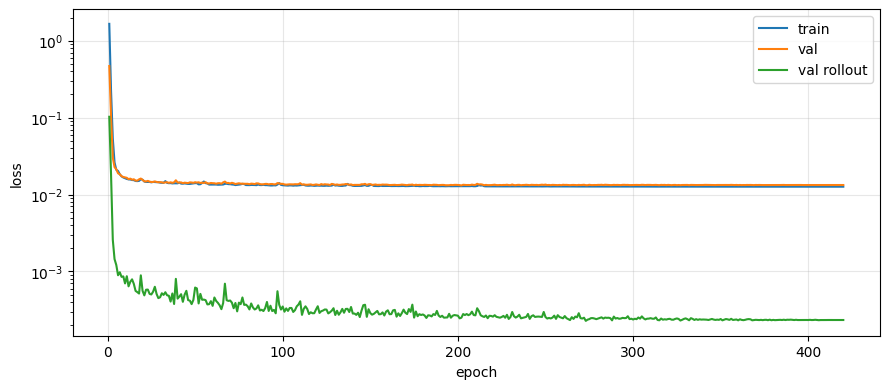

In [13]:
plt.figure(figsize=(9, 4))
plt.semilogy(history['epoch'], history['train_loss'], label='train')
plt.semilogy(history['epoch'], history['val_loss'], label='val')
if 'val_rollout_loss' in history.columns:
    plt.semilogy(history['epoch'], history['val_rollout_loss'], label='val rollout')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'training_curve.png')
plt.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()

## 9. One-Step Test Evaluation

In [14]:
@torch.no_grad()
def predict_delta_physical(model, df):
    X = torch.tensor(df[FEAT_COLS].values, dtype=torch.float32).to(device)
    Xn = (X - model.Xm) / model.Xs
    dn = model(Xn)
    dp = model.denorm_delta(dn, add_mean=True)
    return dp.cpu().numpy()


def one_step_metrics(model, df, name):
    pred = predict_delta_physical(model, df)
    true = df[TGT_COLS].values
    rows = []
    for i, col in enumerate(TGT_COLS):
        err = pred[:, i] - true[:, i]
        rows.append({
            'split': name,
            'target': col,
            'rmse': float(np.sqrt(np.mean(err**2))),
            'mae': float(np.mean(np.abs(err))),
            'std_true': float(np.std(true[:, i])),
        })
    return pd.DataFrame(rows)


metrics_one = pd.concat([
    one_step_metrics(model, train_df, 'train'),
    one_step_metrics(model, val_df, 'val'),
    one_step_metrics(model, test_df, 'test'),
], ignore_index=True)
metrics_one.to_csv(os.path.join(SAVE_DIR, 'one_step_metrics.csv'), index=False)
metrics_one

,split,target,rmse,mae,std_true
0,train,dh,0.006785,0.005339,0.204845
1,train,dV,0.000275,0.000194,0.049539
2,train,dtheta,0.000011,0.000008,0.000917
3,train,dq,0.000040,0.000030,0.004271
4,train,dalpha,0.000015,0.000009,0.000614
5,val,dh,0.006910,0.005290,0.201002
6,val,dV,0.000377,0.000254,0.048361
7,val,dtheta,0.000022,0.000015,0.000938
8,val,dq,0.000069,0.000047,0.003812
9,val,dalpha,0.000025,0.000016,0.000598


Saved: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/one_step_scatter.png


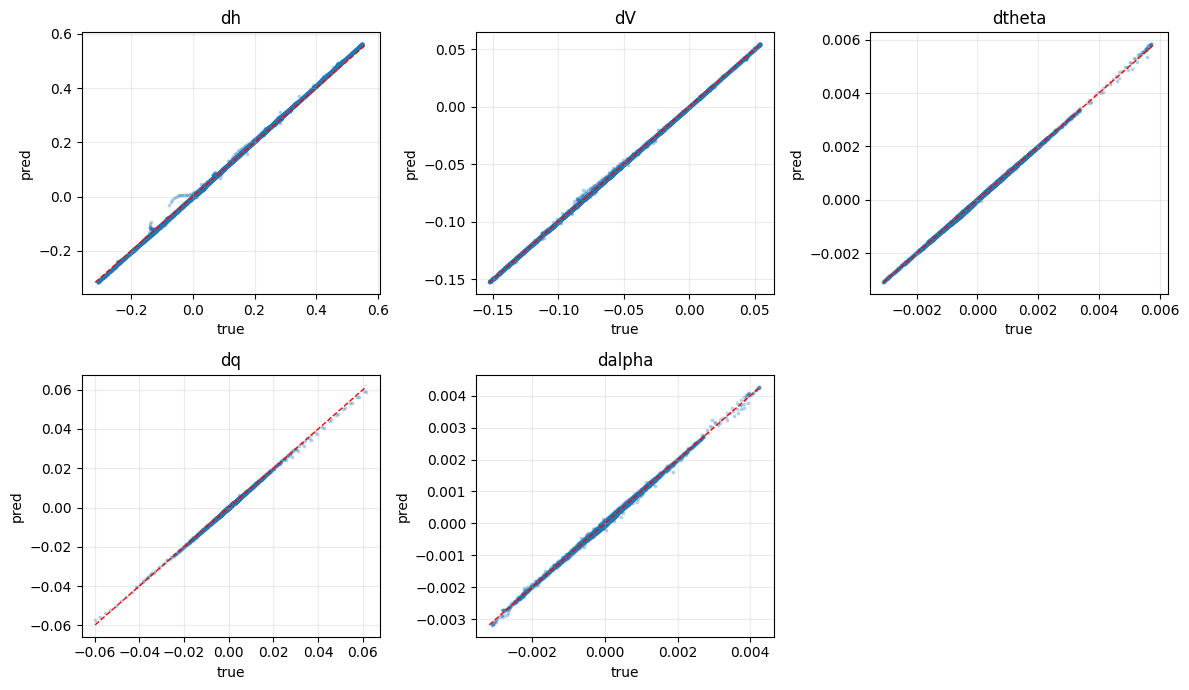

In [15]:
pred_test = predict_delta_physical(model, test_df)
true_test = test_df[TGT_COLS].values
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col, i in zip(axes.ravel(), TGT_COLS, range(len(TGT_COLS))):
    ax.scatter(true_test[:, i], pred_test[:, i], s=3, alpha=0.25)
    lo = min(true_test[:, i].min(), pred_test[:, i].min())
    hi = max(true_test[:, i].max(), pred_test[:, i].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(col)
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
    ax.grid(True, alpha=0.25)
axes.ravel()[-1].axis('off')
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'one_step_scatter.png')
plt.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()


## 10. Multi-Step Rollout Evaluation

For MPC, rollout accuracy matters more than one-step accuracy. This section compares a recursive PINN rollout against a JSBSim trajectory.

In [16]:
def rollout_pinn(model, init_state, elevator_seq, throttle_seq=None):
    model.eval()
    elev_seq = np.asarray(elevator_seq, dtype=np.float32)
    if throttle_seq is None:
        throttle_seq = np.ones_like(elev_seq, dtype=np.float32) * INIT_THROTTLE
    throttle_seq = np.asarray(throttle_seq, dtype=np.float32)
    n_seq = min(len(elev_seq), len(throttle_seq))
    elev_seq = elev_seq[:n_seq]
    throttle_seq = throttle_seq[:n_seq]
    states = [np.asarray(init_state, dtype=np.float32).copy()]
    current = states[0].copy()

    if n_seq == 0:
        return np.asarray(states)

    prev_elev = float(elev_seq[0])
    prev_throttle = float(throttle_seq[0])
    for k in range(1, n_seq):
        elev = float(elev_seq[k])
        throttle = float(throttle_seq[k])
        delevator = elev - prev_elev
        dthrottle = throttle - prev_throttle
        x = np.array([*current, elev, throttle, prev_elev, prev_throttle, delevator, dthrottle], dtype=np.float32)
        xt = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
        xn = (xt - model.Xm) / model.Xs
        with torch.no_grad():
            dn = model(xn)
            delta = model.denorm_delta(dn, add_mean=True).cpu().numpy()[0]
        current = current + delta
        states.append(current.copy())
        prev_elev = elev
        prev_throttle = throttle
    return np.asarray(states)


def jsbsim_trajectory(init_alt, init_speed, init_pitch, elevator_seq, throttle_seq=None):
    elev_seq = np.asarray(elevator_seq, dtype=np.float32)
    if throttle_seq is None:
        throttle_seq = np.ones_like(elev_seq, dtype=np.float32) * INIT_THROTTLE
    throttle_seq = np.asarray(throttle_seq, dtype=np.float32)
    n_seq = min(len(elev_seq), len(throttle_seq))
    elev_seq = elev_seq[:n_seq]
    throttle_seq = throttle_seq[:n_seq]
    init_throttle = float(throttle_seq[0]) if n_seq else INIT_THROTTLE
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch, init_throttle=init_throttle)

    if n_seq == 0:
        return np.asarray([read_state(fdm)])

    fdm['fcs/elevator-cmd-norm'] = float(elev_seq[0])
    fdm['fcs/throttle-cmd-norm'] = float(throttle_seq[0])
    fdm.run()
    states = [read_state(fdm).copy()]

    for k in range(1, n_seq):
        fdm['fcs/elevator-cmd-norm'] = float(elev_seq[k])
        fdm['fcs/throttle-cmd-norm'] = float(throttle_seq[k])
        fdm.run()
        states.append(read_state(fdm).copy())
    return np.asarray(states)


def make_elevator_signal_rng(n_steps, mode, rng):
    t = np.arange(n_steps) * DT
    if mode == 'smooth_random':
        elev = np.zeros(n_steps, dtype=np.float32)
        for i in range(1, n_steps):
            elev[i] = 0.94 * elev[i-1] + 0.06 * rng.uniform(-ELEV_LIMIT, ELEV_LIMIT)
        return np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
    if mode == 'sine':
        amp = rng.uniform(0.08, 0.28)
        freq = rng.uniform(0.03, 0.18)
        phase = rng.uniform(0, 2*np.pi)
        return np.clip(amp * np.sin(2*np.pi*freq*t + phase), -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
    if mode == 'steps':
        elev = np.zeros(n_steps, dtype=np.float32)
        hold = int(rng.integers(25, 100))
        val = 0.0
        for i in range(n_steps):
            if i % hold == 0:
                val = rng.uniform(-0.40, 0.40)
                hold = int(rng.integers(25, 120))
            elev[i] = val
        return np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
    if mode == 'chirp':
        amp = rng.uniform(0.08, 0.26)
        f0, f1 = 0.03, rng.uniform(0.18, 0.45)
        phase = 2*np.pi*(f0*t + 0.5*(f1-f0)/max(t[-1], DT)*t*t)
        return np.clip(amp * np.sin(phase), -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
    if mode == 'doublet':
        elev = np.zeros(n_steps, dtype=np.float32)
        k = int(rng.integers(30, max(31, n_steps - 120)))
        amp = rng.uniform(0.15, 0.35) * rng.choice([-1.0, 1.0])
        width = int(rng.integers(12, 35))
        elev[k:k+width] = amp
        elev[k+width:k+2*width] = -amp
        return np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
    if mode == 'energy_sweep':
        return make_elevator_signal_rng(n_steps, 'smooth_random', rng)
    raise ValueError(mode)


def make_throttle_signal_rng(n_steps, mode, rng, init_throttle=INIT_THROTTLE):
    t = np.arange(n_steps) * DT
    base = np.clip(float(init_throttle), THROTTLE_MIN, THROTTLE_MAX)
    if mode == 'smooth_random':
        thr = np.ones(n_steps, dtype=np.float32) * base
        for i in range(1, n_steps):
            target = rng.uniform(THROTTLE_MIN, THROTTLE_MAX)
            thr[i] = 0.985 * thr[i-1] + 0.015 * target
        return limit_rate(np.clip(thr, THROTTLE_MIN, THROTTLE_MAX), DTHROTTLE_LIMIT)
    if mode == 'sine':
        amp = rng.uniform(0.04, 0.14)
        freq = rng.uniform(0.015, 0.09)
        phase = rng.uniform(0, 2*np.pi)
        return limit_rate(np.clip(base + amp * np.sin(2*np.pi*freq*t + phase), THROTTLE_MIN, THROTTLE_MAX), DTHROTTLE_LIMIT)
    if mode == 'steps':
        thr = np.ones(n_steps, dtype=np.float32) * base
        hold = int(rng.integers(50, 160))
        val = base
        for i in range(n_steps):
            if i % hold == 0:
                val = rng.uniform(THROTTLE_MIN, THROTTLE_MAX)
                hold = int(rng.integers(50, 180))
            thr[i] = val
        return limit_rate(np.clip(thr, THROTTLE_MIN, THROTTLE_MAX), DTHROTTLE_LIMIT)
    if mode == 'chirp':
        amp = rng.uniform(0.04, 0.12)
        f0, f1 = 0.01, rng.uniform(0.08, 0.22)
        phase = 2*np.pi*(f0*t + 0.5*(f1-f0)/max(t[-1], DT)*t*t)
        return limit_rate(np.clip(base + amp * np.sin(phase), THROTTLE_MIN, THROTTLE_MAX), DTHROTTLE_LIMIT)
    if mode == 'doublet':
        thr = np.ones(n_steps, dtype=np.float32) * base
        k = int(rng.integers(50, max(51, n_steps - 160)))
        amp = rng.uniform(0.08, 0.18) * rng.choice([-1.0, 1.0])
        width = int(rng.integers(25, 70))
        thr[k:k+width] = base + amp
        thr[k+width:k+2*width] = base - amp
        return limit_rate(np.clip(thr, THROTTLE_MIN, THROTTLE_MAX), DTHROTTLE_LIMIT)
    if mode == 'energy_sweep':
        thr = np.linspace(rng.uniform(0.55, 0.75), rng.uniform(0.80, 1.00), n_steps, dtype=np.float32)
        if rng.random() < 0.5:
            thr = thr[::-1].copy()
        ripple = 0.03 * np.sin(2*np.pi*rng.uniform(0.02, 0.08)*t + rng.uniform(0, 2*np.pi))
        return limit_rate(np.clip(thr + ripple, THROTTLE_MIN, THROTTLE_MAX), DTHROTTLE_LIMIT)
    raise ValueError(mode)


def build_fixed_rollout_cases(n_cases, n_steps, seed):
    rng = np.random.default_rng(seed)
    modes = ['smooth_random', 'sine', 'steps', 'chirp', 'doublet', 'energy_sweep']
    cases = []
    for case in range(n_cases):
        mode = modes[case % len(modes)]
        init_alt = float(rng.uniform(2300, 6000))
        init_speed = float(rng.uniform(85, 115))
        init_pitch = float(rng.uniform(-5, 8))
        init_throttle = float(rng.uniform(0.60, 0.95))
        elev = make_elevator_signal_rng(n_steps, mode, rng)
        throttle = make_throttle_signal_rng(n_steps, mode, rng, init_throttle=init_throttle)
        actual = jsbsim_trajectory(init_alt, init_speed, init_pitch, elev, throttle)
        cases.append({
            'case': case,
            'mode': mode,
            'init_alt': init_alt,
            'init_speed': init_speed,
            'init_pitch': init_pitch,
            'init_throttle': init_throttle,
            'elevator': elev,
            'throttle': throttle,
            'actual': actual,
        })
    return cases


def eval_rollout_cases(model, cases):
    rows = []
    packed = []
    for item in cases:
        elev = item['elevator']
        throttle = item['throttle']
        actual = item['actual']
        pred = rollout_pinn(model, actual[0], elev, throttle)

        n = min(len(actual), len(pred))
        actual_cmp = actual[:n]
        pred_cmp = pred[:n]
        err = pred_cmp - actual_cmp
        row = {'case': item['case'], 'mode': item['mode']}
        for i, col in enumerate(STATE_COLS):
            row[f'{col}_rmse'] = float(np.sqrt(np.mean(err[:, i]**2)))
            row[f'{col}_max_abs'] = float(np.max(np.abs(err[:, i])))
        rows.append(row)
        packed.append((item['mode'], elev[:n], throttle[:n], actual_cmp, pred_cmp))
    return pd.DataFrame(rows), packed


rollout_val_cases = build_fixed_rollout_cases(N_ROLLOUT_VAL_CASES, ROLLOUT_STEPS, ROLLOUT_VAL_SEED)
rollout_test_cases = build_fixed_rollout_cases(N_ROLLOUT_TEST_CASES, ROLLOUT_STEPS, ROLLOUT_TEST_SEED)

rollout_metrics, rollout_cases = eval_rollout_cases(model, rollout_val_cases)
rollout_metrics.to_csv(os.path.join(SAVE_DIR, 'rollout_metrics_initial_val.csv'), index=False)
rollout_metrics


,case,mode,h_rmse,h_max_abs,V_rmse,V_max_abs,theta_rmse,theta_max_abs,q_rmse,q_max_abs,alpha_rmse,alpha_max_abs
0,0,smooth_random,0.233605,0.444092,0.007310,0.017410,0.000500,0.001120,0.000342,0.000753,0.000075,0.000136
1,1,sine,0.127528,0.175781,0.008696,0.022537,0.000701,0.001405,0.001313,0.002268,0.000186,0.000457
2,2,steps,0.207389,0.411621,0.018410,0.034515,0.000218,0.000384,0.001967,0.005207,0.000351,0.000760
3,3,chirp,0.130983,0.170898,0.014006,0.030960,0.000158,0.000294,0.000534,0.001085,0.000117,0.000229
4,4,doublet,0.606945,1.193115,0.023739,0.031601,0.000416,0.000667,0.001119,0.003098,0.000205,0.000534
5,5,energy_sweep,0.754507,1.334961,0.011770,0.033966,0.000419,0.000842,0.000603,0.001263,0.000108,0.000206
6,6,smooth_random,0.132203,0.172363,0.014076,0.023880,0.001013,0.001968,0.000559,0.001377,0.000089,0.000175
7,7,sine,0.685490,1.434814,0.020658,0.050934,0.000467,0.000798,0.002024,0.004585,0.000461,0.001047
8,8,steps,0.196656,0.517090,0.071164,0.146637,0.000845,0.001670,0.001710,0.003313,0.000213,0.000461
9,9,chirp,0.166863,0.245605,0.015483,0.021240,0.000673,0.001563,0.000633,0.001053,0.000074,0.000127


## 10-1. Automatic q-aware Continue Training

After the initial training pass, this section checks rollout metrics on a fixed validation rollout set. If `q_rmse` or other target metrics are above the thresholds, the model continues training in chunks. Only checkpoints that improve the fixed-set rollout score are kept.

In [17]:
def rollout_summary_score(metrics_df):
    h = float(metrics_df['h_rmse'].mean())
    theta = float(metrics_df['theta_rmse'].mean())
    q = float(metrics_df['q_rmse'].mean())
    score = h / TARGET_H_RMSE_FT + theta / TARGET_THETA_RMSE_RAD + q / TARGET_Q_RMSE_RAD_S
    ok = (h <= TARGET_H_RMSE_FT) and (theta <= TARGET_THETA_RMSE_RAD) and (q <= TARGET_Q_RMSE_RAD_S)
    return score, ok, {'h_rmse_mean': h, 'theta_rmse_mean': theta, 'q_rmse_mean': q}


auto_log = []
score, ok, summary = rollout_summary_score(rollout_metrics)
best_rollout_score = score
best_rollout_summary = dict(summary)
best_rollout_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
best_cycle = 0
print('Initial fixed rollout summary:', summary, 'score=', round(score, 3), 'ok=', ok)

if AUTO_TRAIN:
    current_lr = BEST_PARAMS.get('lr', LR)
    for cycle in range(1, AUTO_MAX_CYCLES + 1):
        if ok:
            print(f'[PASS] target reached before cycle {cycle}')
            break

        # Always restart from the best rollout checkpoint before trying another chunk.
        model.load_state_dict({k: v.to(device) for k, v in best_rollout_state.items()})

        current_lr *= AUTO_LR_DECAY
        chunk_params = dict(BEST_PARAMS)
        chunk_params['epochs'] = AUTO_CHUNK_EPOCHS
        chunk_params['lr'] = current_lr
        chunk_params['target_weights'] = TARGET_WEIGHTS

        print(f'\n[AUTO] cycle {cycle}/{AUTO_MAX_CYCLES} | lr={current_lr:.2e} | epochs={AUTO_CHUNK_EPOCHS}')
        model, hist_extra, val_extra = train_model(chunk_params, verbose=True, initial_model=model)

        extra = hist_extra.copy()
        extra['auto_cycle'] = cycle
        history = pd.concat([history, extra], ignore_index=True)

        rollout_metrics, rollout_cases = eval_rollout_cases(model, rollout_val_cases)
        score, ok, summary = rollout_summary_score(rollout_metrics)
        row = {'cycle': cycle, 'score': score, 'ok': ok, **summary}
        auto_log.append(row)
        print('[AUTO] fixed rollout summary:', row)

        if score < best_rollout_score:
            best_rollout_score = score
            best_rollout_summary = dict(summary)
            best_rollout_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_cycle = cycle
            print('[AUTO] best rollout checkpoint updated')
        else:
            print('[AUTO] no fixed-rollout improvement; keeping previous best checkpoint')

    model.load_state_dict({k: v.to(device) for k, v in best_rollout_state.items()})

rollout_val_metrics, rollout_val_packed = eval_rollout_cases(model, rollout_val_cases)
rollout_test_metrics, rollout_cases = eval_rollout_cases(model, rollout_test_cases)
rollout_metrics = rollout_test_metrics
score_test, ok_test, summary_test = rollout_summary_score(rollout_test_metrics)

metrics_one = pd.concat([
    one_step_metrics(model, train_df, 'train'),
    one_step_metrics(model, val_df, 'val'),
    one_step_metrics(model, test_df, 'test'),
], ignore_index=True)

AUTO_SUMMARY = {
    'best_cycle': int(best_cycle),
    'best_rollout_score_val': float(best_rollout_score),
    'best_h_rmse_mean_val': float(best_rollout_summary['h_rmse_mean']),
    'best_theta_rmse_mean_val': float(best_rollout_summary['theta_rmse_mean']),
    'best_q_rmse_mean_val': float(best_rollout_summary['q_rmse_mean']),
    'final_rollout_score_test': float(score_test),
    'final_h_rmse_mean_test': float(summary_test['h_rmse_mean']),
    'final_theta_rmse_mean_test': float(summary_test['theta_rmse_mean']),
    'final_q_rmse_mean_test': float(summary_test['q_rmse_mean']),
    'test_targets_met': bool(ok_test),
    'auto_cycles_run': int(len(auto_log)),
    'auto_restart_policy': 'restart_each_cycle_from_best_rollout_checkpoint',
}

auto_log_df = pd.DataFrame(auto_log)
auto_log_df.to_csv(os.path.join(SAVE_DIR, 'auto_training_log.csv'), index=False)
history.to_csv(os.path.join(SAVE_DIR, 'training_history_auto.csv'), index=False)
metrics_one.to_csv(os.path.join(SAVE_DIR, 'one_step_metrics_auto.csv'), index=False)
rollout_val_metrics.to_csv(os.path.join(SAVE_DIR, 'rollout_metrics_auto_val.csv'), index=False)
rollout_test_metrics.to_csv(os.path.join(SAVE_DIR, 'rollout_metrics_auto_test.csv'), index=False)

print('\nFinal one-step metrics:')
display(metrics_one)
print('\nFinal fixed validation rollout metrics:')
display(rollout_val_metrics)
print('\nFinal fixed test rollout metrics:')
display(rollout_test_metrics)
print('\nAuto summary:')
print(json.dumps(AUTO_SUMMARY, indent=2))
print('\nAuto training log:')
display(auto_log_df)

Initial fixed rollout summary: {'h_rmse_mean': 0.3242169409990311, 'theta_rmse_mean': 0.0005410125391790644, 'q_rmse_mean': 0.0010804211691720412} score= 0.262 ok= True
[PASS] target reached before cycle 1

Final one-step metrics:


,split,target,rmse,mae,std_true
0,train,dh,0.006785,0.005339,0.204845
1,train,dV,0.000275,0.000194,0.049539
2,train,dtheta,0.000011,0.000008,0.000917
3,train,dq,0.000040,0.000030,0.004271
4,train,dalpha,0.000015,0.000009,0.000614
5,val,dh,0.006910,0.005290,0.201002
6,val,dV,0.000377,0.000254,0.048361
7,val,dtheta,0.000022,0.000015,0.000938
8,val,dq,0.000069,0.000047,0.003812
9,val,dalpha,0.000025,0.000016,0.000598



Final fixed validation rollout metrics:


,case,mode,h_rmse,h_max_abs,V_rmse,V_max_abs,theta_rmse,theta_max_abs,q_rmse,q_max_abs,alpha_rmse,alpha_max_abs
0,0,smooth_random,0.233605,0.444092,0.007310,0.017410,0.000500,0.001120,0.000342,0.000753,0.000075,0.000136
1,1,sine,0.127528,0.175781,0.008696,0.022537,0.000701,0.001405,0.001313,0.002268,0.000186,0.000457
2,2,steps,0.207389,0.411621,0.018410,0.034515,0.000218,0.000384,0.001967,0.005207,0.000351,0.000760
3,3,chirp,0.130983,0.170898,0.014006,0.030960,0.000158,0.000294,0.000534,0.001085,0.000117,0.000229
4,4,doublet,0.606945,1.193115,0.023739,0.031601,0.000416,0.000667,0.001119,0.003098,0.000205,0.000534
5,5,energy_sweep,0.754507,1.334961,0.011770,0.033966,0.000419,0.000842,0.000603,0.001263,0.000108,0.000206
6,6,smooth_random,0.132203,0.172363,0.014076,0.023880,0.001013,0.001968,0.000559,0.001377,0.000089,0.000175
7,7,sine,0.685490,1.434814,0.020658,0.050934,0.000467,0.000798,0.002024,0.004585,0.000461,0.001047
8,8,steps,0.196656,0.517090,0.071164,0.146637,0.000845,0.001670,0.001710,0.003313,0.000213,0.000461
9,9,chirp,0.166863,0.245605,0.015483,0.021240,0.000673,0.001563,0.000633,0.001053,0.000074,0.000127



Final fixed test rollout metrics:


,case,mode,h_rmse,h_max_abs,V_rmse,V_max_abs,theta_rmse,theta_max_abs,q_rmse,q_max_abs,alpha_rmse,alpha_max_abs
0,0,smooth_random,0.402827,0.682129,0.013009,0.021088,0.000646,0.001461,0.000290,0.000665,0.000090,0.000188
1,1,sine,0.102875,0.135742,0.013933,0.034286,0.000605,0.000834,0.000396,0.000734,0.000165,0.000251
2,2,steps,0.515873,1.050781,0.013575,0.020294,0.000474,0.000740,0.001476,0.002822,0.000143,0.000379
3,3,chirp,0.066828,0.133057,0.008563,0.014267,0.000110,0.000200,0.000549,0.001289,0.000231,0.000957
4,4,doublet,0.479637,0.932861,0.029464,0.042404,0.000517,0.000798,0.001085,0.003275,0.000200,0.000574
5,5,energy_sweep,0.225086,0.576660,0.044632,0.073685,0.000388,0.000600,0.000659,0.001649,0.000154,0.000350
6,6,smooth_random,0.064734,0.086914,0.011386,0.017593,0.000810,0.001551,0.000792,0.001401,0.000111,0.000206
7,7,sine,0.216885,0.380127,0.029268,0.049362,0.000628,0.001009,0.000836,0.001677,0.000173,0.000319
8,8,steps,0.212188,0.489258,0.019578,0.042603,0.000336,0.000934,0.001235,0.003375,0.000266,0.000847
9,9,chirp,0.168104,0.237793,0.013514,0.018738,0.000615,0.001327,0.000678,0.001583,0.000194,0.000464



Auto summary:
{
  "best_cycle": 0,
  "best_rollout_score_val": 0.2617944882147842,
  "best_h_rmse_mean_val": 0.3242169409990311,
  "best_theta_rmse_mean_val": 0.0005410125391790644,
  "best_q_rmse_mean_val": 0.0010804211691720412,
  "final_rollout_score_test": 0.20196115210872245,
  "final_h_rmse_mean_test": 0.24550377652049066,
  "final_theta_rmse_mean_test": 0.0005130001845827792,
  "final_q_rmse_mean_test": 0.0007997382170287892,
  "test_targets_met": true,
  "auto_cycles_run": 0,
  "auto_restart_policy": "restart_each_cycle_from_best_rollout_checkpoint"
}

Auto training log:


""


Saved: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/rollout_validation.png


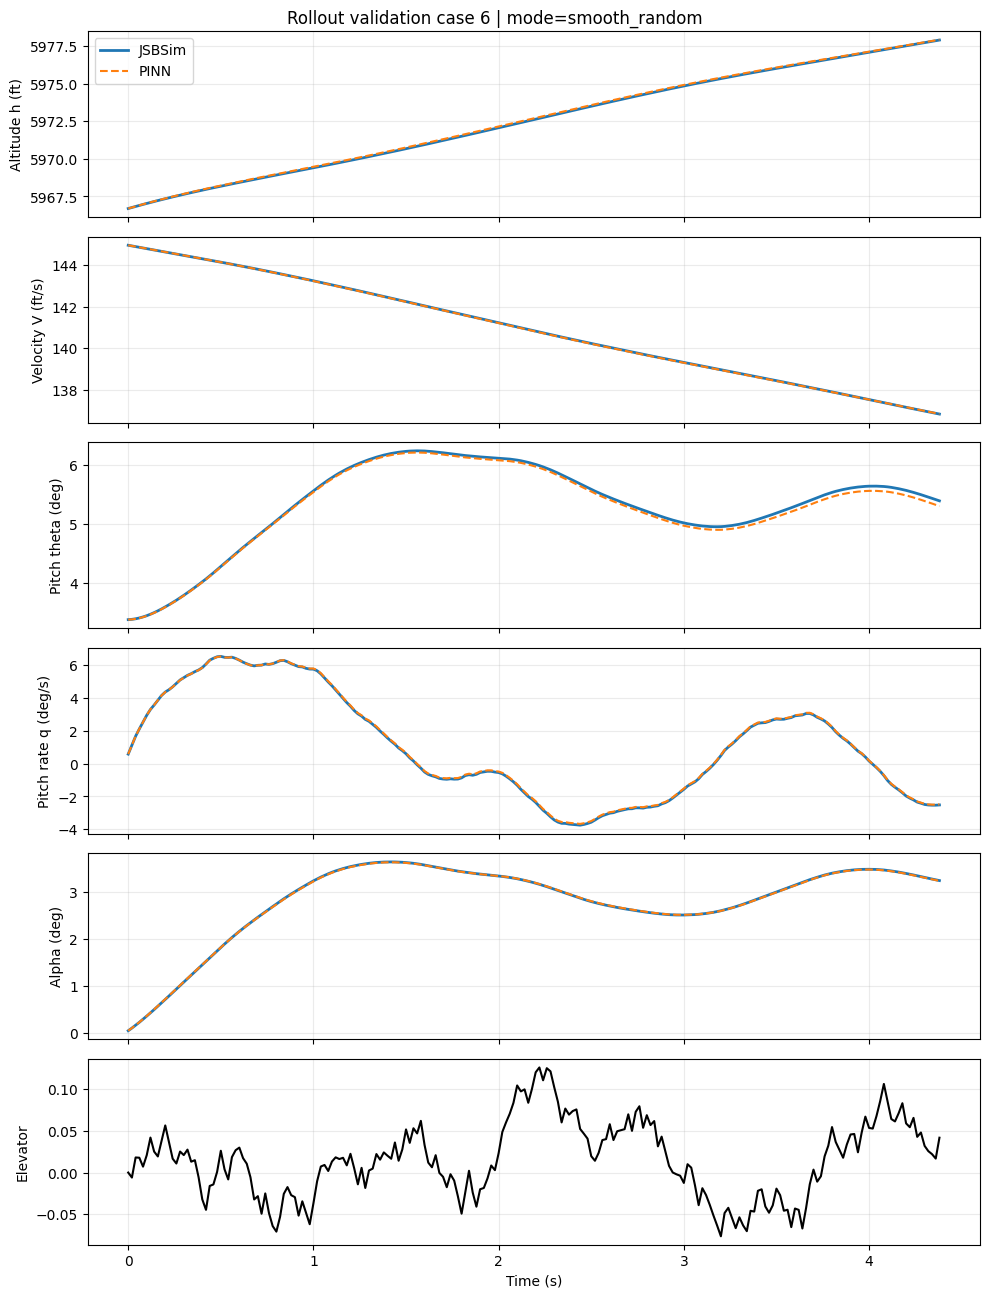

In [18]:
case_idx = int(rollout_metrics['h_rmse'].idxmin()) if len(rollout_metrics) else 0
mode, elev, throttle, actual, pred = rollout_cases[case_idx]
t = np.arange(len(actual)) * DT

n_state = len(STATE_COLS)
fig, axes = plt.subplots(n_state + 1, 1, figsize=(10, 2.2 * (n_state + 1)), sharex=True)
labels = {
    'h': 'Altitude h (ft)',
    'V': 'Velocity V (ft/s)',
    'theta': 'Pitch theta (deg)',
    'q': 'Pitch rate q (deg/s)',
    'alpha': 'Alpha (deg)',
}

for i, col in enumerate(STATE_COLS):
    a = actual[:, i].copy()
    p = pred[:, i].copy()
    if col in ['theta', 'q', 'alpha']:
        a = np.degrees(a)
        p = np.degrees(p)
    axes[i].plot(t, a, label='JSBSim', lw=2)
    axes[i].plot(t, p, '--', label='PINN', lw=1.5)
    axes[i].set_ylabel(labels.get(col, col))
    axes[i].grid(True, alpha=0.25)

axes[-1].plot(np.arange(len(elev)) * DT, elev, color='k')
axes[-1].set_ylabel('Elevator')
axes[-1].set_xlabel('Time (s)')
axes[-1].grid(True, alpha=0.25)
axes[0].legend()
fig.suptitle(f'Rollout validation case {case_idx} | mode={mode}')
plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'rollout_validation.png')
plt.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()

## 11. Save PINN Checkpoint

The saved checkpoint can be loaded later from the MPC notebook.

In [19]:
checkpoint = {
    'model_state': model.state_dict(),
    'stats': {k: v.cpu() for k, v in stats.items()},
    'config': CONFIG,
    'best_params': BEST_PARAMS,
    'auto_summary': AUTO_SUMMARY,
    'auto_training_log': auto_log_df.to_dict(orient='records'),
    'feature_cols': FEAT_COLS,
    'target_cols': TGT_COLS,
    'state_cols': STATE_COLS,
    'input_cols': INPUT_COLS,
    'dt': DT,
    'input_contract': MODEL_INPUT_CONTRACT,
    'checkpoint_version': 'v7_alpha_throttle',
    'one_step_metrics': metrics_one.to_dict(orient='records'),
    'rollout_val_metrics': rollout_val_metrics.to_dict(orient='records'),
    'rollout_test_metrics': rollout_test_metrics.to_dict(orient='records'),
    'rollout_metrics': rollout_test_metrics.to_dict(orient='records'),
}
ckpt_path = os.path.join(SAVE_DIR, CHECKPOINT_FILENAME)
torch.save(checkpoint, ckpt_path)

summary_path = os.path.join(SAVE_DIR, SUMMARY_FILENAME)
with open(summary_path, 'w') as f:
    json.dump({
        'config': CONFIG,
        'best_params': BEST_PARAMS,
        'best_val_loss_initial_training': float(best_val),
        'auto_summary': AUTO_SUMMARY,
        'checkpoint': ckpt_path,
        'input_contract': MODEL_INPUT_CONTRACT,
        'feature_cols': FEAT_COLS,
        'target_cols': TGT_COLS,
    }, f, indent=2)

print('Saved checkpoint:', ckpt_path)
print('Saved summary:', summary_path)


Saved checkpoint: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/pinn_dynamics_c172_2d_v7_alpha_throttle.pt
Saved summary: /content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/pinn_training_summary_v7_alpha_throttle.json


## 12. Loading Example for MPC Notebook

In [20]:
# Minimal loading example for a future MPC notebook.
# v7 throttle uses augmented inputs:
# [h, V, theta, q, alpha, elevator, throttle, prev_elevator, prev_throttle, delevator, dthrottle]
# The model predicts [dh, dV, dtheta, dq, dalpha]. MPC state must carry alpha.
#
# checkpoint = torch.load('/content/drive/MyDrive/PINN_MODEL_ONLY_v2_throttle/pinn_dynamics_c172_2d_v7_alpha_throttle.pt', map_location=device)
# stats_loaded = checkpoint['stats']
# model_loaded = PhysicsPINN(
#     hidden_dim=checkpoint['best_params']['hidden_dim'],
#     n_layers=checkpoint['best_params']['n_layers'],
#     stats=stats_loaded,
# ).to(device)
# model_loaded.load_state_dict(checkpoint['model_state'])
# model_loaded.eval()
# print('Loaded v7 alpha-throttle PINN dynamics model')
